# Lab 2.1 — Zero vs Few-shot Crossover

We run the same classification task at k = 0, 1, 3, 5 shots and plot
accuracy vs. number of shots.

**Watch for:** on a strong instruction-tuned model, zero-shot may already be
near-ceiling on an easy task — the interesting result is finding a task
*hard enough* that shots visibly help, and seeing where they stop helping.
This demo deliberately uses **sarcasm / tone-ambiguous** sentences, which
tend to trip up zero-shot.

## Cache redirect — point Hugging Face downloads at your NFS volume

The pod's local disk is small and can fill up fast once you're downloading
multi-GB model weights (this is what causes `disk is full` errors when
saving). Redirect the Hugging Face cache to your larger, persistent NFS
volume **before** any model is loaded.

**Edit the volume name below to match yours** (check with `ls ~` in a
terminal if you're not sure).

In [1]:
import os

# WHY THIS CELL EXISTS:
# Hugging Face downloads model weights (100s of MB to several GB) into a
# cache directory. By default that's on the pod's small local disk which
# fills up fast. We redirect the cache to the larger NFS volume BEFORE
# importing transformers, so all downloads land in the right place.

NFS_CACHE_ROOT = os.path.expanduser("~/llmall/.cache")   # <-- edit volume name to match yours

# HF_HOME       -> where model weights, tokenizers, configs are cached
# HF_DATASETS_CACHE -> where 'datasets' library caches its downloads
os.environ["HF_HOME"] = os.path.join(NFS_CACHE_ROOT, "huggingface")
os.environ["HF_DATASETS_CACHE"] = os.path.join(NFS_CACHE_ROOT, "datasets")
os.makedirs(os.environ["HF_HOME"], exist_ok=True)
os.makedirs(os.environ["HF_DATASETS_CACHE"], exist_ok=True)

print("HF cache redirected to:", os.environ["HF_HOME"])


HF cache redirected to: /home/jovyan/llmall/.cache/huggingface


## Setup — Local model via `transformers` (CPU-only, no API credits needed)

We're running a small model **locally** instead of calling a hosted API —
no per-request cost, and it works even if the Inference API is rate-limited
or out of credits.

**Kubeflow users:** do not request a GPU — these models are small enough
(0.5B–1.5B parameters) to run at acceptable speed on CPU for a live demo.

**Token:** not required for the models used here — they're public,
ungated repos. If you ever swap in a gated model, reuse the `HF_TOKEN`
setup from earlier and pass `token=HF_TOKEN` to `from_pretrained(...)`.

**If you see a `torch`/`torchvision`/`torchaudio` version-conflict warning**
during install, or a `torchvision::nms does not exist` error when loading
the model: these notebooks don't need `torchvision` or `torchaudio` at all.
Run this once and restart the kernel:
```bash
pip uninstall -y torchvision torchaudio
```

In [2]:
import sys
print(sys.executable)

/home/jovyan/data/venv/bin/python


In [3]:
!pip install --quiet -U transformers accelerate matplotlib
!pip install --quiet torch  # only installs if missing -- avoids upgrading an existing torch and breaking any torchvision/torchaudio pinned to it
print("Packages installed/upgraded. If this is the first install this session, restart the kernel now, then run from the top.")

Packages installed/upgraded. If this is the first install this session, restart the kernel now, then run from the top.


In [4]:
# WHY THIS CELL EXISTS:
# On a shared CPU pod, PyTorch/OpenMP will greedily grab ALL visible cores
# by default, which causes thrashing and slow inference. We pin thread
# counts to match our actual CPU quota so generation runs cleanly.

import os
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # silences a warning; safe for single-process use

import torch
torch.set_num_threads(6)          # intra-op parallelism (inside a single matmul)
torch.set_num_interop_threads(1)  # inter-op parallelism (across ops); 1 avoids over-subscription


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "Qwen/Qwen2.5-0.5B-Instruct"

print(f"Loading {MODEL} ... (first run downloads the weights)")

# STEP 1: TOKENIZER
# Downloads (or loads from cache) the vocab + merge rules + special tokens
# for this checkpoint. Converts text <-> token IDs.
tokenizer = AutoTokenizer.from_pretrained(MODEL)

# STEP 2: MODEL WEIGHTS
# Downloads (or loads from cache) architecture + pretrained weights.
#   torch_dtype=torch.float32 -> full precision, most CPU-compatible
#   device_map="cpu"          -> keep everything on CPU (no GPU here)
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float32, device_map="cpu")

# STEP 3: INFERENCE MODE
# Disables dropout / training-only behaviours -> deterministic, consistent outputs.
model.eval()

print("Model ready.")


Loading Qwen/Qwen2.5-0.5B-Instruct ... (first run downloads the weights)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model ready.


### How few-shot works in a chat model

In a chat model, few-shot examples aren't just glued onto the prompt as raw
text — they're inserted as **prior conversational turns**. The pattern is:

```
system:    "Classify sentiment as positive or negative."
user:      <example_1_text>
assistant: <example_1_label>       <-- shot 1
user:      <example_2_text>
assistant: <example_2_label>       <-- shot 2
...
user:      <the real message we actually want classified>
```

The model sees this as a conversation it has already been participating in
correctly, so it continues the pattern for the final user turn. This is
why `classify()` below builds a `messages` list and appends alternating
user/assistant entries for each shot — that's the whole few-shot mechanism.


In [6]:
def classify(text, shots, max_tokens=5):
    """Classify `text` as 'positive' or 'negative' using k-shot prompting.

    Args:
        text:  the sentence to classify.
        shots: list of (example_text, example_label) tuples — the few-shot examples.
               Pass [] for zero-shot.
        max_tokens: cap on generated tokens (5 is plenty for a one-word answer).
    """

    # STEP 1: system message defines the task and the output contract
    messages = [{
        "role": "system",
        "content": "Classify the sentiment of the message as exactly one "
                    "word: positive or negative. Respond with only that word."
    }]

    # STEP 2: inject each shot as a completed user->assistant turn.
    # This is the few-shot pattern: the model sees prior examples where the
    # "assistant" (itself) already responded correctly, and continues the pattern.
    for ex_text, ex_label in shots:
        messages.append({"role": "user", "content": ex_text})
        messages.append({"role": "assistant", "content": ex_label})

    # STEP 3: append the real query as the final user turn
    messages.append({"role": "user", "content": text})

    # STEP 4: apply chat template -> tokenize -> generate
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens=max_tokens,
            do_sample=False,                         # greedy -> deterministic classification
            pad_token_id=tokenizer.eos_token_id,
        )

    # STEP 5: strip off the prompt tokens, decode, normalize
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    reply = tokenizer.decode(new_tokens, skip_special_tokens=True)
    # normalize: strip whitespace, lowercase, drop trailing period
    # (defends against "Positive.", "  positive", etc.)
    return reply.strip().lower().strip(".")


## Data — Regular and deliberately tricky eval set (sarcasm / mixed tone)

In [7]:
# "Regular" set — plainly stated sentiment
regular_eval_set = [
    ("I really loved the movie, it was fantastic from start to finish.", "positive"),
    ("This is the worst customer service I've ever experienced.", "negative"),
    ("The food was absolutely delicious and beautifully presented.", "positive"),
    ("I'm so disappointed, the product arrived broken.", "negative"),
    ("What a wonderful surprise, thank you so much for this!", "positive"),
    ("This app crashes constantly and it's driving me crazy.", "negative"),
    ("I had an amazing time at the concert last night.", "positive"),
    ("The instructions were confusing and the setup was a nightmare.", "negative"),
    ("Great job on the presentation, genuinely impressive work.", "positive"),
    ("I can't stand how slow and unreliable this service has become.", "negative"),
]

regular_shot_pool = [
    ("I absolutely loved this book, couldn't put it down.", "positive"),
    ("The service was terrible and the staff were incredibly rude.", "negative"),
    ("This works perfectly, exactly what I needed.", "positive"),
    ("I regret buying this, it stopped working within a week.", "negative"),
    ("What a fantastic experience, I'll definitely come back.", "positive"),
]

In [8]:
def run_shot_sweep(eval_set, shot_pool, shot_counts=(0, 1, 3, 5), label=""):
    """Run the same eval set at multiple shot counts (k) and return per-k accuracy.

    Args:
        eval_set:   list of (text, true_label) — held-out test items.
        shot_pool:  list of (text, label) — pool to draw few-shot examples from.
                    IMPORTANT: must NOT overlap with eval_set (otherwise we'd
                    be leaking test answers into the prompt).
        shot_counts: which k values to sweep — default (0, 1, 3, 5).
        label:      just a tag for the print output (e.g. "regular" / "sarcastic").
        Calls classify function which creates a prompt and generates an,the  answer
    """
    accuracies = {}
    for k in shot_counts:
        shots = shot_pool[:k]                             # take first k examples as our shots
        correct = 0
        for text, true_label in eval_set:
            pred = classify(text, shots)                  # run classification at this k
            # Robust label matching: accept "positive"/"pos..." as positive,
            # "negative"/"neg..." as negative; anything else stays as-is (will fail match).
            pred_label = "positive" if "pos" in pred else ("negative" if "neg" in pred else pred)
            correct += int(pred_label == true_label)
        acc = correct / len(eval_set)
        accuracies[k] = acc
        print(f"[{label}] k={k}: accuracy = {acc:.0%}")
    return accuracies


In [9]:
regular_accuracies = run_shot_sweep(regular_eval_set, regular_shot_pool, label="regular")

/home/jovyan/data/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/jovyan/data/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/jovyan/data/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


[regular] k=0: accuracy = 100%
[regular] k=1: accuracy = 90%
[regular] k=3: accuracy = 100%
[regular] k=5: accuracy = 100%


In [10]:
eval_set = [
    ("Oh great, another Monday. Just what I needed.", "negative"),
    ("Wow, this is exactly the surprise I was hoping for!", "positive"),
    ("Sure, take your time, it's not like I have anywhere to be.", "negative"),
    ("I can't believe how smoothly that went, genuinely impressed.", "positive"),
    ("Fantastic, the one day I forget my umbrella it pours.", "negative"),
    ("Honestly didn't expect much but this blew me away.", "positive"),
    ("Perfect, more paperwork, my favorite thing in the world.", "negative"),
    ("This turned out way better than I imagined, love it.", "positive"),
    ("Great, the meeting got moved up an hour. Love last-minute changes.", "negative"),
    ("Never thought I'd say this about a Monday, but today was great.", "positive"),
]

# A separate pool used only for few-shot examples (never overlaps eval_set)
shot_pool = [
    ("Oh wonderful, my flight got delayed again.", "negative"),
    ("This is genuinely the best coffee I've had all year.", "positive"),
    ("Just perfect, my laptop crashed right before the deadline.", "negative"),
    ("I was skeptical but this exceeded every expectation.", "positive"),
    ("Terrific, another meeting that could\'ve been an email.", "negative"),
]

In [11]:
sarcastic_accuracies = run_shot_sweep(eval_set, shot_pool, label="sarcastic")

[sarcastic] k=0: accuracy = 70%
[sarcastic] k=1: accuracy = 50%
[sarcastic] k=3: accuracy = 50%
[sarcastic] k=5: accuracy = 50%


## Plot accuracy vs. number of shots

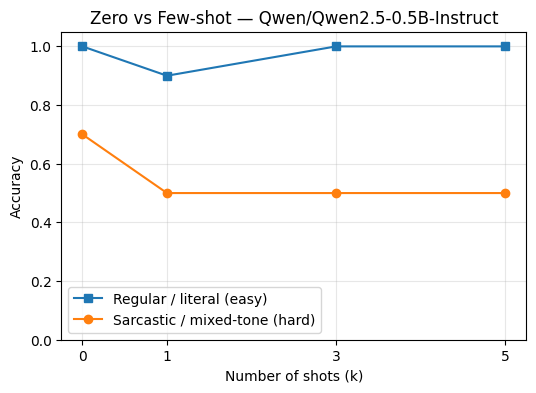

In [12]:
# Plot accuracy vs. k for both eval sets on the same axes.
# The "crossover" story of the lab lives in comparing the two curves:
# - Regular set may be near-ceiling even at k=0 (little room for shots to help)
# - Sarcastic set typically starts low and climbs as k increases,
#   sometimes plateauing or dipping past a certain k.
import matplotlib.pyplot as plt

ks = [0, 1, 3, 5]

plt.figure(figsize=(6, 4))
plt.plot(ks, [regular_accuracies[k] for k in ks], marker="s", label="Regular / literal (easy)")
plt.plot(ks, [sarcastic_accuracies[k] for k in ks], marker="o", label="Sarcastic / mixed-tone (hard)")
plt.xlabel("Number of shots (k)")
plt.ylabel("Accuracy")
plt.title(f"Zero vs Few-shot — {MODEL}")
plt.ylim(0, 1.05)
plt.xticks(ks)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Why sarcasm accuracy can *drop* as k increases

**1. Small-sample noise.** With only 10 test items, one flip = 10 percentage points. Small drops between k values are often noise, not a real trend. Always re-run 2–3 times before drawing conclusions.

**2. Shots teach a spurious surface pattern.** Our sarcastic shots all start with positive-sounding words ("wonderful", "perfect", "Terrific") that turn out to mean *negative*. At higher k, the model over-generalizes this to *"positive-sounding openers = sarcasm = negative"* — and then misclassifies genuinely positive test items that happen to start with positive words.

**3. Recency bias in the prompt.** The model gives more weight to context nearest the query. If the last few shots skew negative, the model develops a mild bias toward predicting negative on ambiguous items.

**4. Over-anchoring narrows the model's prior.** Zero-shot, the model draws on its full training. With shots, it narrows to *"the kind of sarcasm shown in these examples"* — which may not cover the sarcasm styles in the eval set. More shots = tighter anchor = more brittleness on off-pattern items.

---

Shots don't just teach the *task* — they also teach the *pattern of the specific examples you picked*. When those patterns don't match the test distribution, more shots can make things **worse**. This motivates the next-level questions: **which** examples to include, **how diverse** they should be, and in **what order** — not just how many.

## Discussion 

- If accuracy is already high at k=0: this model is well instruction-tuned
  for sentiment; try swapping in a smaller/older model to make the
  crossover visible, or make the eval set harder (more sarcasm, mixed
  signals).

- **Takeaway:** more shots is not free — each one is reprocessed on every
  call (cost), and past a task-dependent point, extra shots stop helping or
  actively hurt. The right number of shots is an empirical question, not a
  default of "more is better."

## ICL is presentation-sensitive

**ICL** = *In-Context Learning* — the technical name for what few-shot
prompting actually is. The model isn't being *trained* on the shots
(no gradient update happens); it's using the shots as *context* to
condition its next prediction. This is a much shallower kind of "learning"
than fine-tuning, and it comes with a catch worth naming clearly:

**The model's answer depends not just on WHICH examples are in the prompt,
but on HOW they're presented.** The same k shots can steer the model
differently depending on:

- **Order** — which shot appears first vs last (recency bias),
- **Label balance** — are most shots positive or most negative? (majority-label bias),
- **Wording style** — do the shots share surface patterns the model can latch onto?

The two experiments below isolate the first two of these. Each one holds
*everything* constant — same model, same k, same eval set, same shot
content — and varies only presentation. Any change in prediction
you see is caused **purely by presentation**, not by the model or the task.


In [17]:
# Order sensitivity
# Fix the 4 shots. Only shuffle their order. Do predictions change?

import itertools, random
random.seed(0)   # deterministic sample of orderings, so class results are reproducible

base_shots = shot_pool[:4]                                   # same content every time -- only order changes
all_orderings = list(itertools.permutations(base_shots))     # 4! = 24 possible orderings of 4 shots
sample_orderings = random.sample(all_orderings, k=5)         # pick 5 distinct orderings (running all 24 is overkill)

# For each eval item, get one prediction PER ordering.
# order_predictions[text] -> list of 5 predictions (one per ordering).
order_predictions = {}
for text, true_label in eval_set:
    preds = []
    for shots in sample_orderings:
        pred = classify(text, list(shots))
        pred_label = "positive" if "pos" in pred else ("negative" if "neg" in pred else pred)
        preds.append(pred_label)
    order_predictions[text] = preds

# An eval item is "unstable" if its 5 predictions weren't unanimous —
# i.e. shot order alone changed the model's answer.
unstable = [text for text, preds in order_predictions.items() if len(set(preds)) > 1]

print(f"Order sensitivity: {len(unstable)}/{len(eval_set)} eval items changed prediction "
      f"purely because of shot ORDER (content identical every time)\n")
for text in unstable:
    print(f"  '{text[:50]}...' -> {order_predictions[text]}")


Order sensitivity: 0/10 eval items changed prediction purely because of shot ORDER (content identical every time)



In [18]:

# Label-balance (majority-label) sensitivity
# Two shot sets, same k=4, same sarcastic style — but one is
# all-negative and the other is all-positive. Do predictions
# on the SAME eval set shift toward the majority label?


# Shot set A: all negative labels (sarcastic-style openers, negative meaning)
majority_negative_shots = [
    ("Oh wonderful, my flight got delayed again.", "negative"),
    ("Just perfect, my laptop crashed right before the deadline.", "negative"),
    ("Terrific, another meeting that could've been an email.", "negative"),
    ("Great, my package got lost in transit again.", "negative"),
]

# Shot set B: all positive labels (genuine positive statements)
majority_positive_shots = [
    ("This is genuinely the best coffee I've had all year.", "positive"),
    ("I was skeptical but this exceeded every expectation.", "positive"),
    ("What a fantastic surprise, I loved every bit of it.", "positive"),
    ("This turned out even better than I hoped for.", "positive"),
]


def run_balance_test(shots, label):
    """Classify every eval item with the given shots and report the positive-rate.

    If shots didn't bias the model, the positive-rate would be the same regardless
    of which shot set is used. If they DO bias, the positive-rate under
    all-positive shots will be noticeably higher than under all-negative shots.
    """
    preds = {}
    for text, true_label in eval_set:
        pred = classify(text, shots)
        pred_label = "positive" if "pos" in pred else ("negative" if "neg" in pred else pred)
        preds[text] = pred_label
    pos_rate = sum(1 for p in preds.values() if p == "positive") / len(preds)
    print(f"[{label}] predicted-positive rate: {pos_rate:.0%}")
    return preds


# Run both conditions and keep the per-item predictions for comparison
neg_biased_preds = run_balance_test(majority_negative_shots, "all-negative shots")
pos_biased_preds = run_balance_test(majority_positive_shots, "all-positive shots")

# Items that FLIPPED between the two conditions -- pure label-balance effect
# (same eval text, same model, same k=4, only shot labels differ)
flipped = [text for text, _ in eval_set if neg_biased_preds[text] != pos_biased_preds[text]]
print(f"\n{len(flipped)}/{len(eval_set)} eval items flipped prediction purely because of "
      f"which label dominated the shots (same eval text, same model, same k=4)\n")
for text in flipped:
    print(f"  '{text[:50]}...' -> neg-biased: {neg_biased_preds[text]}, pos-biased: {pos_biased_preds[text]}")


[all-negative shots] predicted-positive rate: 80%
[all-positive shots] predicted-positive rate: 100%

2/10 eval items flipped prediction purely because of which label dominated the shots (same eval text, same model, same k=4)

  'Sure, take your time, it's not like I have anywher...' -> neg-biased: negative, pos-biased: positive
  'Fantastic, the one day I forget my umbrella it pou...' -> neg-biased: negative, pos-biased: positive


## Discussion 

- Any nonzero count in either instability check is the finding — it means
  the model changed its answer on a *fixed* eval item without the eval
  item, the model, or the shot *content* changing at all. Only order or
  label balance moved. A **0/10 order-sensitivity result is a legitimate
  finding too** — order effects are well-documented in the ICL literature,
  but they don't show up on every model/task/k combination. 
  
- **Majority-label bias is usually the stronger, more reliable effect of
  the two**, but watch for it being **asymmetric** rather than a clean
  symmetric tug-of-war: check the predicted-positive rate under each
  condition. If one direction (e.g. all-positive shots) pushes much
  further than the other (e.g. all-negative shots stopping short of
  100%), that tells you the model already has its own default lean before
  you added any shots — the shots are reinforcing an existing bias in one
  direction and fighting against it in the other, not starting from
  neutral ground.
- **Look at *which* eval items flip, not just how many.** If the items
  that flip are sarcasm- or tone-dependent (surface words that read one
  way but mean the other), that's the more precise version of the
  takeaway: label bias does the most damage exactly where the model's
  understanding was already weakest, not uniformly across the eval set.
  The clearly unambiguous items typically hold steady regardless of shot
  bias — it's the borderline cases that get dragged around.
- **Takeaway:** order and majority-label bias are real, measurable effects
  — not edge cases — and label bias compounds with whatever bias the
  model already has rather than acting as a neutral push. A "few-shot
  prompt" isn't a single well-defined input; the same set of examples can
  push the model in different directions depending on how they're
  arranged, and it hits hardest on the eval items that were already
  borderline. This is exactly why the next part moves toward *retrieving*
  relevant examples per query rather than hand-picking a fixed set once
  and reusing it everywhere.

## Dynamic shot selection (embedding retrieval)

Everything so far has used **static** few-shot: pick k shots once, reuse
them for every query. But the "right" shots depend on the query — a
sarcastic message benefits from sarcastic shots, a literal one from
literal shots. A fixed set is at best a compromise across all query types.

**Dynamic shot selection** flips this: keep a **larger pool** of candidate
examples, and *per query*, pick the k most similar to that specific query.
Same k, same model, same eval set — only the shots change per item.

**How "similar" is measured — embeddings.** We turn each text (both the
query and every pool item) into a fixed-length **vector** using a small
pretrained embedding model. Semantically similar sentences produce vectors
that point in similar directions in that vector space. Similarity between
two texts then becomes a simple math operation: the **cosine** of the
angle between their vectors (or, when vectors are unit-normalized, just
their dot product).

**Why this matters conceptually.** The mechanism below — embed query,
compare to a corpus of pre-embedded items, take top-k, insert into prompt
— is exactly what a **RAG (Retrieval-Augmented Generation)** pipeline
does. The only difference: RAG retrieves *document chunks* to answer
questions; here we retrieve *few-shot examples* to condition
classification.

In [20]:
# One-time install: sentence-transformers gives us a small, CPU-friendly
# embedding model. If already installed, this is a no-op.
!pip install --quiet sentence-transformers

In [21]:
from sentence_transformers import SentenceTransformer
import numpy as np

# STEP 1: Load the embedding model.
# all-MiniLM-L6-v2 is a small (~22M param), fast, CPU-friendly encoder
# that maps any sentence to a 384-dim vector. 
# production RAG typically uses bigger/better encoders.
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# STEP 2: Build a larger, more diverse pool than the fixed 3-5 used earlier.
# For retrieval to be interesting, the pool must contain BOTH sentiments
# and a range of styles -- otherwise there's nothing meaningful to pick between.
large_shot_pool = [
    ("Oh wonderful, my flight got delayed again.", "negative"),
    ("This is genuinely the best coffee I've had all year.", "positive"),
    ("Just perfect, my laptop crashed right before the deadline.", "negative"),
    ("I was skeptical but this exceeded every expectation.", "positive"),
    ("Terrific, another meeting that could've been an email.", "negative"),
    ("What a fantastic surprise, I loved every bit of it.", "positive"),
    ("Great, my package got lost in transit again.", "negative"),
    ("This turned out even better than I hoped for.", "positive"),
    ("Sure, add more paperwork, exactly what my day needed.", "negative"),
    ("Never expected to enjoy this as much as I did.", "positive"),
]

# STEP 3: Pre-compute embeddings for the ENTIRE pool, ONCE.
# This is a key efficiency point: at query time we only need to embed the
# incoming query (fast); pool embeddings are already cached.
# normalize_embeddings=True forces each vector to unit length, which makes
# cosine similarity equivalent to a simple dot product (Step 4 below).
pool_texts = [t for t, _ in large_shot_pool]
pool_embeddings = embedder.encode(pool_texts, convert_to_numpy=True,
                                   normalize_embeddings=True)


def retrieve_similar_shots(query, k=3):
    """Return the k pool items whose embeddings are closest to `query`.

    "Closest" = highest cosine similarity in the embedding space.
    Because both sides are normalized, cosine similarity = dot product.
    """
    # Embed the incoming query (single-item batch, so we index [0])
    query_emb = embedder.encode([query], convert_to_numpy=True,
                                 normalize_embeddings=True)[0]

    # Similarity of query against every pool item, in one matrix multiply.
    # pool_embeddings has shape (N_pool, 384); query_emb has shape (384,);
    # result `sims` has shape (N_pool,) -- one similarity score per pool item.
    sims = pool_embeddings @ query_emb

    # argsort(sims) sorts ASCENDING; [::-1] reverses to descending;
    # [:k] takes the top k indices.
    top_k_idx = np.argsort(sims)[::-1][:k]

    return [large_shot_pool[i] for i in top_k_idx]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
# Quick intuition: an embedding is just a vector of numbers.
demo_vec = embedder.encode(["What a great day!"])[0]
print(f"Sentence -> vector of shape {demo_vec.shape}")
print(f"First 8 dims: {demo_vec[:8]}")

Sentence -> vector of shape (384,)
First 8 dims: [-0.0455375   0.0758708   0.07178282 -0.03378949 -0.02938452  0.00574182
  0.0979704  -0.02253888]


In [22]:
# Fixed shots vs Retrieved shots
# Same k=3, same pool, same model, same eval set.
# The ONLY variable: fixed uses the first 3 pool items for
# EVERY query; retrieved picks 3 shots per query by similarity.


fixed_shots = large_shot_pool[:3]   # same 3 shots reused for every eval item


def run_shot_strategy(strategy):
    """Run the full eval set under one strategy and return accuracy.

    strategy = "fixed"      -> always use `fixed_shots`
    strategy = "retrieved"  -> pick 3 shots per query via embedding similarity
    """
    correct = 0
    for text, true_label in eval_set:
        # THE KEY BRANCH: this one line is the entire experimental difference.
        shots = fixed_shots if strategy == "fixed" else retrieve_similar_shots(text, k=3)

        pred = classify(text, shots)
        # Same robust label normalization we've used throughout
        pred_label = "positive" if "pos" in pred else ("negative" if "neg" in pred else pred)
        correct += int(pred_label == true_label)
    return correct / len(eval_set)


fixed_acc = run_shot_strategy("fixed")
retrieved_acc = run_shot_strategy("retrieved")

print(f"Fixed 3-shot accuracy:     {fixed_acc:.0%}")
print(f"Retrieved 3-shot accuracy: {retrieved_acc:.0%}")

/home/jovyan/data/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/jovyan/data/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/jovyan/data/venv/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Fixed 3-shot accuracy:     50%
Retrieved 3-shot accuracy: 60%


In [25]:
for text, true_label in eval_set[:3]:
    print(f"Query: {text}")
    print("Retrieved shots:")
    for shot_text, shot_label in retrieve_similar_shots(text, k=3):
        print(f"  - ({shot_label}) {shot_text}")
    print()

Query: Oh great, another Monday. Just what I needed.
Retrieved shots:
  - (negative) Sure, add more paperwork, exactly what my day needed.
  - (negative) Terrific, another meeting that could've been an email.
  - (negative) Oh wonderful, my flight got delayed again.

Query: Wow, this is exactly the surprise I was hoping for!
Retrieved shots:
  - (positive) What a fantastic surprise, I loved every bit of it.
  - (positive) This turned out even better than I hoped for.
  - (positive) I was skeptical but this exceeded every expectation.

Query: Sure, take your time, it's not like I have anywhere to be.
Retrieved shots:
  - (negative) Sure, add more paperwork, exactly what my day needed.
  - (negative) Great, my package got lost in transit again.
  - (negative) Terrific, another meeting that could've been an email.



## Discussion 

- **Retrieved beat fixed, 60% vs 50%** — real, but that's a single flipped
  item out of 10. At n=10, one item is a
  10-point swing. This is a genuine improvement, not a huge one — worth
  re-running with a larger eval set before treating "+10%" as a robust
  number rather than noise-adjacent.

- **Look closely at *why* retrieval worked here** — The retrieved shots aren't
  just topically similar, they're matching the exact **sarcastic
  template**: "another Monday... just what I needed" retrieved "add more
  paperwork... exactly what my day needed" and "another meeting that
  could've been an email" — same rhetorical shape (ironic "exactly what I
  needed" framing), not just similar subject matter. The embedding model
  is picking up on *phrasing style*, and in this dataset, phrasing style
  happens to correlate strongly with sentiment label, because both the
  eval set and shot pool were written by the same hand in a consistent
  sarcastic register.

  This is a smaller, more homogeneous dataset than a real deployment would have —
  embedding similarity is doing well partly because the eval and shot
  pool share a stylistic fingerprint. In a messier real-world pool (shots
  written by different people, different domains, genuinely varied
  phrasing), retrieval still helps, but the margin you'd see wouldn't be
  guaranteed to replicate this cleanly. 

- **Takeaway:** this is the bridge from few-shot prompting (a fixed,
  hand-picked prompt) to retrieval / context engineering (dynamically
  assembling context per request). The mechanism — embed the query, find
  the closest matches, insert them into the prompt — is exactly what a
  RAG pipeline does at a larger scale with documents instead of examples.
  The lesson isn't "retrieval always wins by a clean margin" — it's that
  *what gets retrieved*, and *why it's similar*, matters more than the
  accuracy delta alone, and that's exactly the kind of question a real
  RAG system has to answer too.